<a href="https://colab.research.google.com/github/GabrielaRguezCampos/MiamiHeatRecommendationCupon/blob/main/Test_Image_data_50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Set Data (50 only)

In [ ]:
import pandas as pd
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
import gdown

In [ ]:
# Step 0: Download the file
file_id = "1wn9PlD6WooPG1GYRRAw4lKX1WimJu4Sy"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "products_export_50.csv", quiet=False)

# Step 1: Load CSV
df = pd.read_csv('products_export_50.csv')


Downloading...
From: https://drive.google.com/uc?id=1wn9PlD6WooPG1GYRRAw4lKX1WimJu4Sy
To: /content/products_export_50.csv
100%|██████████| 116k/116k [00:00<00:00, 47.4MB/s]


In [ ]:
df.head()


,Handle,Title,Body (HTML),Vendor,Product Category,Type,Tags,Published,Option1 Name,Option1 Value,...,Included / Canada,Price / Canada,Compare At Price / Canada,Included / International,Price / International,Compare At Price / International,Included / australia,Price / australia,Compare At Price / australia,Status
0,miami-heat-jibbitz,Crocs Miami HEAT Logo Jibbitz,<p>Pop some personality into your shoes with t...,Crocs,Apparel & Accessories > Shoe Accessories,Novelties,"color-n-a, color-wh, color-whi, color-white, c...",True,Size,O/S,...,True,NaN,NaN,True,NaN,NaN,True,NaN,NaN,active
1,miami-heat-jibbitz,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,miami-heat-jibbitz,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,24-25-donruss-retail-box,2024-25 Panini Donruss Retail Box,<p><strong>This item is final sale.</strong></...,Sport Images,Arts & Entertainment > Hobbies & Creative Arts...,Novelties,"collectibles, color-n-a, low-stock, new-arriva...",True,Size,O/S,...,True,NaN,NaN,True,NaN,NaN,True,NaN,NaN,active
4,24-25-donruss-retail-box,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:

# Step 2: Drop rows with missing or duplicate image URLs
df = df.dropna(subset=['Image Src'])
df = df.drop_duplicates(subset=['Image Src'])

# Optional: Preview a few images
def download_image(url):
    try:
        response = requests.get(url, timeout=5)
        img = Image.open(BytesIO(response.content)).convert("RGB")
        return img
    except Exception as e:
        print(f"Error downloading {url}: {e}")
        return None

for idx, row in df.head(3).iterrows():
    img = download_image(row['Image Src'])
    if img:
        plt.imshow(img)
        plt.title(row['Title'])
        plt.axis('off')
        plt.show()

### Dominant Color

In [ ]:

# Step 3: Extract dominant color
def get_dominant_color(image, k=10):
    image = image.resize((100, 100))
    data = np.array(image).reshape(-1, 3)
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(data)
    colors = kmeans.cluster_centers_
    counts = np.bincount(kmeans.labels_)
    return colors[np.argmax(counts)].astype(int)

dominant_colors = []

for url in df['Image Src']:
    img = download_image(url)
    if img:
        dominant_color = get_dominant_color(img)
        dominant_colors.append(dominant_color)
    else:
        dominant_colors.append(None)

df['Dominant_Color_RGB'] = dominant_colors



Error downloading https://cdn.shopify.com/s/files/1/1368/0393/files/q2_4706866a-3476-4a98-8fb8-8182e058efec.png?v=1747103919: HTTPSConnectionPool(host='cdn.shopify.com', port=443): Read timed out. (read timeout=5)
Error downloading https://cdn.shopify.com/s/files/1/1368/0393/files/h1_1bfb3850-bc6e-4a00-9db7-af68d5c5fc00.png?v=1747148170: HTTPSConnectionPool(host='cdn.shopify.com', port=443): Read timed out. (read timeout=5)
Error downloading https://cdn.shopify.com/s/files/1/1368/0393/files/h2_67f7f4c1-838f-43a2-a8b3-df25097b50d3.png?v=1747148170: HTTPSConnectionPool(host='cdn.shopify.com', port=443): Read timed out. (read timeout=5)
Error downloading https://cdn.shopify.com/s/files/1/1368/0393/files/t2_190870f0-11b1-4286-915d-564350a55cf0.png?v=1747147283: HTTPSConnectionPool(host='cdn.shopify.com', port=443): Read timed out.
Error downloading https://cdn.shopify.com/s/files/1/1368/0393/files/DSC_6295.png?v=1737038775: HTTPSConnectionPool(host='cdn.shopify.com', port=443): Read timed 

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in by

In [ ]:
# Print the first 5 dominant colors with titles
for idx, row in df.head(5).iterrows():
    print(f"Product: {row['Title']}")
    print(f"Dominant Color (RGB): {row['Dominant_Color_RGB']}\n")


Product: Court Culture Original Vice "MIAMI" Kids Tee
Dominant Color (RGB): [0 0 0]

Product: Court Culture Original Vice "HEAT Basketball" Unisex Crewneck
Dominant Color (RGB): [235 233 233]

Product: nan
Dominant Color (RGB): [233 230 229]

Product: nan
Dominant Color (RGB): [29 27 30]

Product: nan
Dominant Color (RGB): [26 24 26]



### CNN Feature Extraction Using MobileNetV2

In [ ]:
from sklearn.manifold import TSNE
import numpy as np

# Filter valid rows
valid_df = df[df['CNN_Embedding'].notnull()].copy()
embedding_matrix = np.vstack(valid_df['CNN_Embedding'].values)

# Reduce dimensions to 2D for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
reduced = tsne.fit_transform(embedding_matrix)

valid_df['x'] = reduced[:, 0]
valid_df['y'] = reduced[:, 1]


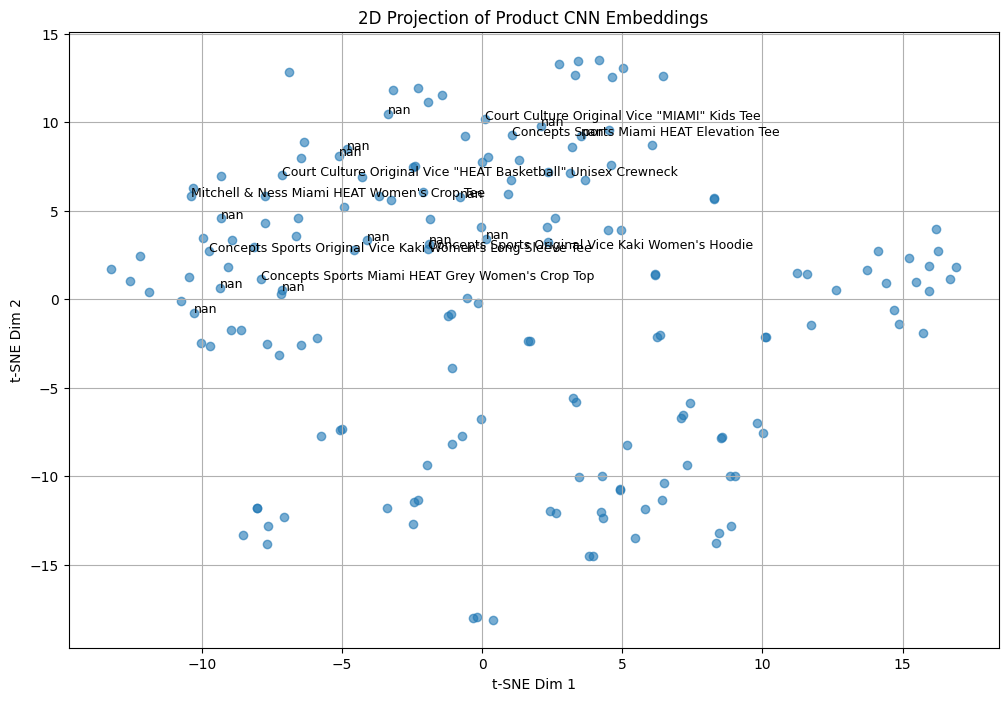

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.scatter(valid_df['x'], valid_df['y'], alpha=0.6)

# Add labels for the first 20 points
for i, row in valid_df.head(20).iterrows():
    plt.text(row['x'], row['y'], row['Title'], fontsize=9)

plt.title("2D Projection of Product CNN Embeddings")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")
plt.grid(True)
plt.show()


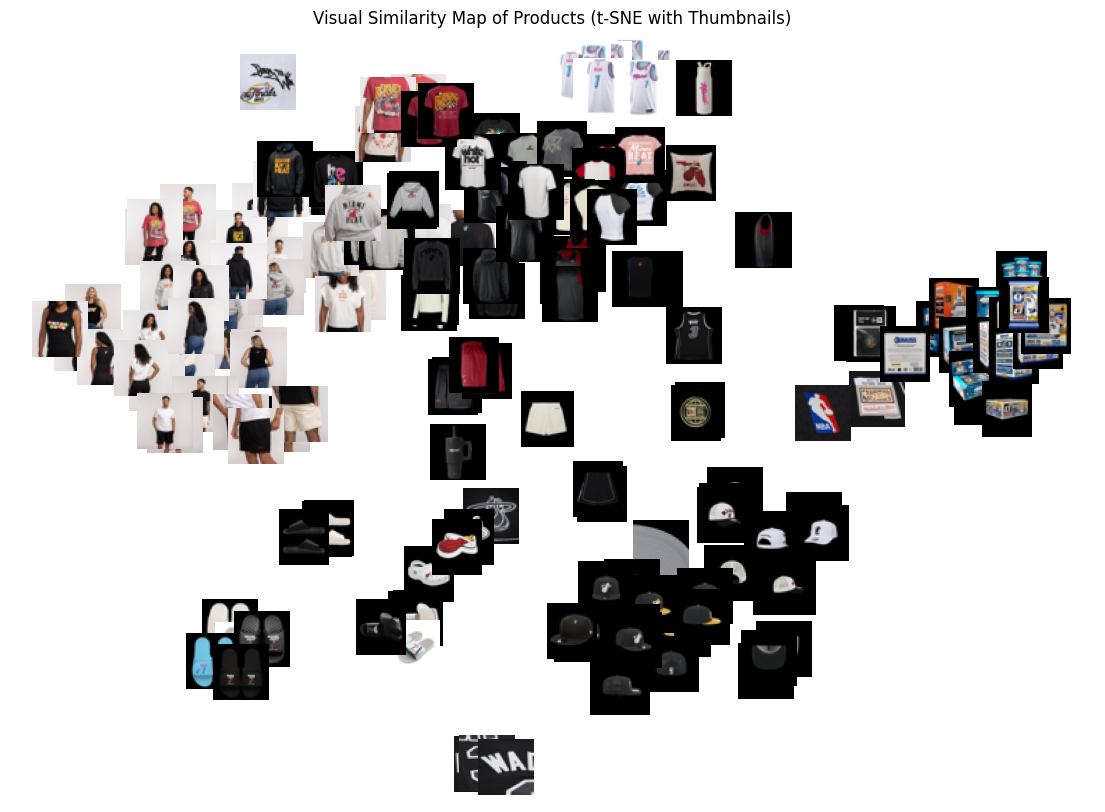

In [ ]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(valid_df['x'], valid_df['y'], alpha=0.5)

for i, row in valid_df.iterrows():
    img = download_image(row['Image Src'])
    if img:
        img.thumbnail((40, 40))  # thumbnail size
        imagebox = OffsetImage(img)
        ab = AnnotationBbox(imagebox, (row['x'], row['y']), frameon=False)
        ax.add_artist(ab)

plt.title("Visual Similarity Map of Products (t-SNE with Thumbnails)")
plt.axis('off')
plt.show()


In [ ]:
# Step 4: Save cleaned + enriched dataset
df.to_csv("cleaned_products_with_image_features.csv", index=False)

### Cosine Similarity Between Images

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Filter only rows with valid embeddings
valid_df = df[df['CNN_Embedding'].notnull()].copy()
embedding_matrix = np.vstack(valid_df['CNN_Embedding'].values)

# Compute cosine similarity matrix
cos_sim = cosine_similarity(embedding_matrix)

# Example: Show most similar products to the first one
target_index = 0
similar_indices = np.argsort(-cos_sim[target_index])[1:4]  # skip self

print(f"Most visually similar products to: {valid_df.iloc[target_index]['Title']}")
for idx in similar_indices:
    title = valid_df.iloc[idx]['Title']
    score = cos_sim[target_index, idx]
    print(f"→ {title} (Similarity: {score:.2f})")


Most visually similar products to: Court Culture Original Vice "MIAMI" Kids Tee
→ Concepts Sports Miami HEAT Elevation Tee (Similarity: 0.69)
→ Nike Miami HEAT White Hot 2025 NBA Playoffs Mantra Tee (Similarity: 0.69)
→ nan (Similarity: 0.64)
